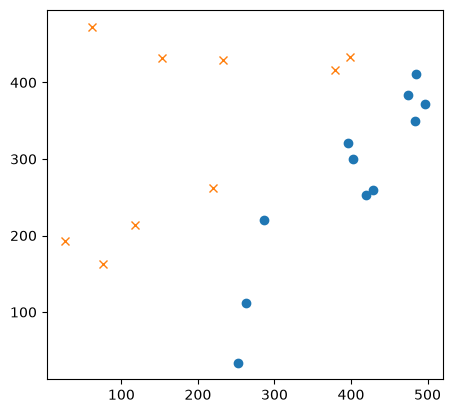

In [56]:
import numpy as np
import matplotlib.pyplot as plt

train = np.loadtxt('images2.csv', delimiter= ',', skiprows=1)
train_x = train[:, 0:2]
train_y = train[:, 2]

plt.plot(train_x[train_y == 1, 0], train_x[train_y == 1, 1], 'o')
plt.plot(train_x[train_y == 0, 0], train_x[train_y == 0, 1], 'x')
plt.axis('scaled')
plt.show()

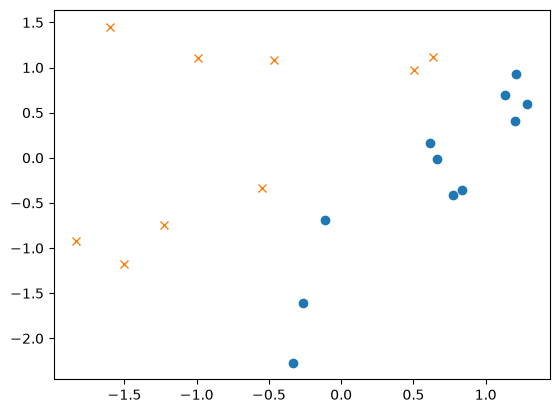

In [57]:
#Parameter initialization
theta = np.random.rand(3)

#Standardization
mu = train_x.mean(axis=0)
sigma = train_x.std(axis=0)

def standardize(x):
    return (x - mu)/sigma
train_z = standardize(train_x)

#增加x0
def to_matrix(x):
    return np.hstack([np.ones((x.shape[0], 1)),x])

X = to_matrix(train_z)

plt.plot(train_z[train_y == 1, 0], train_z[train_y == 1, 1], 'o')
plt.plot(train_z[train_y == 0, 0], train_z[train_y == 0, 1], 'x')
plt.show()

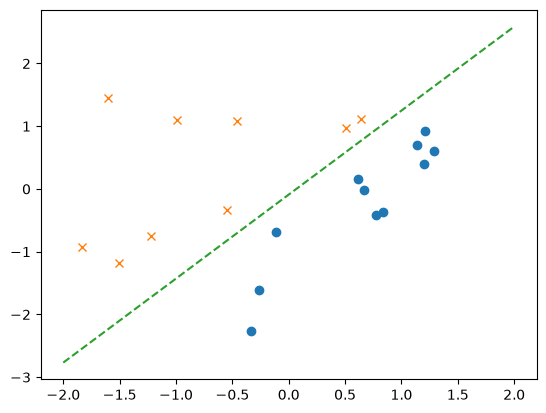

In [58]:
#Prediction function
def f(x):
    return 1 / (1 + np.exp(- np.dot(x, theta)))


#ETA
ETA = 1e-3

#Epoch
epoch = 5000

for _ in range(epoch):
    theta = theta - ETA * np.dot((f(X) - train_y), X)

x1 = np.linspace(-2, 2, 100)

plt.plot(train_z[train_y == 1, 0], train_z[train_y == 1, 1], 'o')
plt.plot(train_z[train_y == 0, 0], train_z[train_y == 0, 1], 'x')
plt.plot(x1, - (theta[0] + theta[1] * x1) / theta[2], linestyle = 'dashed')
plt.show()


In [59]:
f(to_matrix(standardize([
    [200, 100],
    [100, 200]
])))

array([0.91794974, 0.02933185])